In [1]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split


In [2]:
import pandas as pd

df = pd.read_csv("Dataset/diabetes_prediction_dataset.csv")


df
df['gender'] = df['gender'].astype(str).str.strip().str.lower()
df = df[df['gender'] != 'other']
# Map Male = 0, Female = 1
gender_map = {'male': 0, 'female': 1}
df['gender'] = df['gender'].map(gender_map)
df


df['smoking_history'] = df['smoking_history'].astype(str).str.strip().str.lower()

# Step 2: Map into yes / no / former
df['smoking_history'] = df['smoking_history'].replace({
    'current': 'yes',
    'former': 'former',
    'ever': 'former',
    'not current': 'former',
    'never': 'no',
    'no info': 'no'   # or 'unknown' if you want to track that separately
})


smoking_map = {'no': 0, 'former': 1, 'yes': 2}
df['smoking_history'] = df['smoking_history'].map(smoking_map)

df




X = df.drop("diabetes", axis=1)
y = df["diabetes"]



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
df




,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,1,80.0,0,1,0,25.19,6.6,140,0
1,1,54.0,0,0,0,27.32,6.6,80,0
2,0,28.0,0,0,0,27.32,5.7,158,0
3,1,36.0,0,0,2,23.45,5.0,155,0
4,0,76.0,1,1,2,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,1,80.0,0,0,0,27.32,6.2,90,0
99996,1,2.0,0,0,0,17.37,6.5,100,0
99997,0,66.0,0,0,1,27.83,5.7,155,0
99998,1,24.0,0,0,0,35.42,4.0,100,0


In [23]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier



def compare_classifiers(X_train, y_train, X_test, y_test):
    models = {
        "Random Forest": RandomForestClassifier(),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "MLP (Neural Net)": MLPClassifier(max_iter=1000),
        "SVM": SVC(),
        "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
    }
    
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label=1)
        rec = recall_score(y_test, y_pred, pos_label=1)
        f1 = f1_score(y_test, y_pred, pos_label=1)
        
        results.append({
            "Model": name,
            "Accuracy": round(acc, 4),
            "Precision (Class 1)": round(prec, 4),
            "Recall (Class 1)": round(rec, 4),
            "F1-Score (Class 1)": round(f1, 4)
        })
    
    results_df = pd.DataFrame(results)
    print("\nMODEL PERFORMANCE COMPARISON")
    print(results_df.to_string(index=False))
    
    return results_df

# Example usage
results_df = compare_classifiers(X_train, y_train, X_test, y_test)




MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision (Class 1)  Recall (Class 1)  F1-Score (Class 1)
      Random Forest    0.9699               0.9392            0.6912              0.7963
Logistic Regression    0.9618               0.8806            0.6376              0.7397
   MLP (Neural Net)    0.9628               0.8480            0.6859              0.7584
                SVM    0.9485               1.0000            0.3947              0.5660
            XGBoost    0.9709               0.9472            0.6971              0.8031


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:44:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [6]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3]
}

xgb_clf = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)

random_search = RandomizedSearchCV(
    xgb_clf, param_distributions=param_dist,
    n_iter=20, scoring='accuracy', cv=5, verbose=1,
    random_state=42, n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV accuracy:", random_search.best_score_)

best_model = random_search.best_estimator_


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:07:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV accuracy: 0.9720822654247672


In [20]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_xgb = xgb.XGBClassifier(
    subsample= 0.8, #1.0 ,
    n_estimators=200,
    min_child_weight=5,
    max_depth=5, #7,
    learning_rate=0.05,
    gamma=0, #0.1,
    colsample_bytree=0.6, #0.8,
    eval_metric='logloss'
)

# Train on full training data
best_xgb.fit(X_train, y_train)

# Predict on test data
y_pred = best_xgb.predict(X_test)

# Evaluate
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print('ROC AUC :',roc_auc)


Test Accuracy: 0.9723958593789068

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     18297
           1       0.98      0.69      0.81      1700

    accuracy                           0.97     19997
   macro avg       0.98      0.84      0.90     19997
weighted avg       0.97      0.97      0.97     19997


Confusion Matrix:
 [[18279    18]
 [  534  1166]]
ROC AUC : 0.9794520959720172


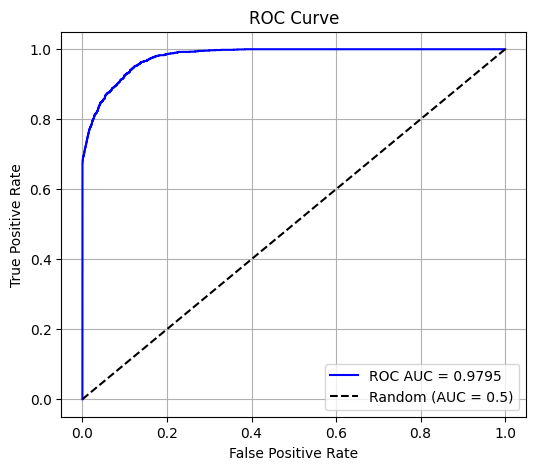

ROC AUC Score: 0.9795


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc, precision_recall_curve

# 1️⃣ Get probabilities for the positive class (class 1)
# best_xgb.predict_proba(X_test) outputs a 2D array where each row corresponds to a test sample. 
# Each row contains two values: the probability that the sample belongs to class 0 and the probability it belongs to class 1.
# [:, 1] selects the probability of the positive class (in your case, class "1" = diabetes).
y_probs = best_xgb.predict_proba(X_test)[:, 1]

# 2️⃣ ROC AUC
roc_auc = roc_auc_score(y_test, y_probs)
fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], 'k--', label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()



# 4️⃣ Print both scores
print(f"ROC AUC Score: {roc_auc:.4f}")


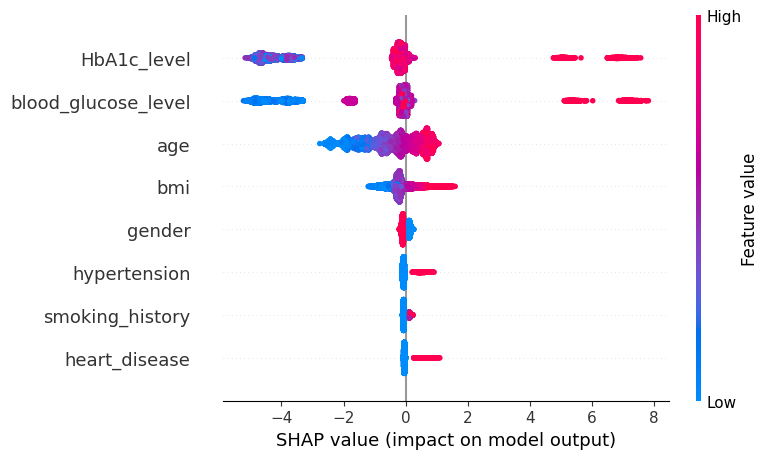

In [15]:
import shap
import matplotlib.pyplot as plt

# Initialize the SHAP TreeExplainer for the best_xgb model
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# 1) Summary Plot: feature importance and effect direction
shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)




